In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9, YlGn_9
from matplotlib.patches import Patch
import contextily as cx

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [35]:
df = pd.read_csv("./Data/Active_Sheds2.csv")  # read csv file

In [36]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["Longitude Point"], df["Latitude Point"]
    ),  # extract from csv file
    crs="EPSG:4326",  # set coordinate reference system
)

gdf.to_file("sheds.fgb", driver="FlatGeobuf")  # convert to fgb file

In [37]:
sheds_data = gpd.read_file("sheds.fgb")

In [38]:
sheds_data.head()

,Job Number,Borough Name,Count Permits,First Permit Date,Current Date,Age,Permit Expiration Date,Sidewalk Shed/Linear Feet,Construction Material,Current Job Status,...,Borough Digit,Block,Lot,Applicant Business Name,ProCert,Source,activity,Commercial,CouncilDistrict,geometry
0,Q01090694-I1,Queens,NaN,8/5/2024,7/17/2026,710,10/7/2026,2170.0,NaN,Permit Entire,...,4,15610,1,MJE PROFESSIONAL SERVICES,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.74192 40.59533)
1,Q01324355-I1,Queens,NaN,11/26/2025,7/17/2026,232,11/26/2026,51.0,NaN,Permit Entire,...,4,15543,35,BANGASH ASSOCIATES INC.,1,DOB NOW,Construction or Maintenance,Other Zoning Districts,31.0,POINT (-73.74978 40.60648)
2,Q01016345-I1,QUEENS,NaN,3/22/2024,7/17/2026,846,8/27/2026,82.0,NaN,Permit Entire,...,4,15557,4,MJE PROFESSIONAL SERVICES,1,DOB NOW,Construction or Maintenance,Commercial District/Overlay,31.0,POINT (-73.74998 40.60294)
3,Q00992128-I1,QUEENS,NaN,1/19/2024,7/17/2026,909,9/5/2026,50.0,NaN,Permit Entire,...,4,15560,34,ASR ENGINEERING PC,1,DOB NOW,Construction or Maintenance,Commercial District/Overlay,31.0,POINT (-73.7503 40.60266)
4,Q01420415-S1,Queens,NaN,7/15/2026,7/17/2026,1,8/31/2026,163.0,NaN,Permit Entire,...,4,15560,8,PAUL PERDEK PROF. ENG. PLLC,1,DOB NOW,Construction or Maintenance,Commercial District/Overlay,31.0,POINT (-73.75158 40.60279)


<Axes: >

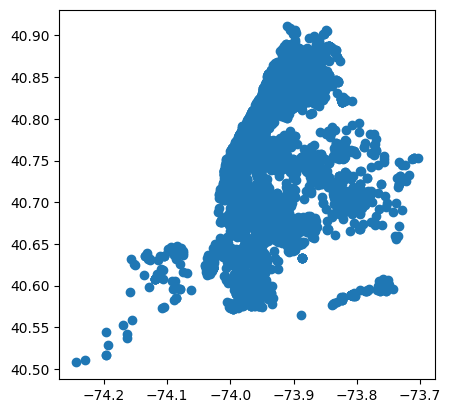

In [39]:
sheds_data.plot()  # first plot

<Axes: >

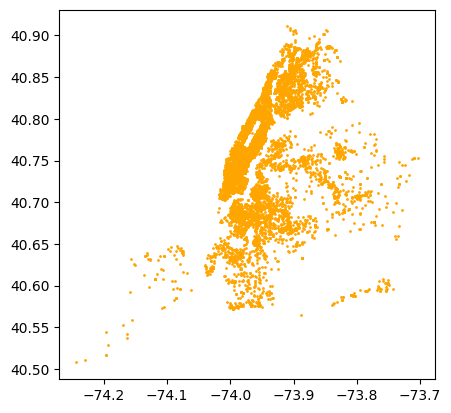

In [40]:
sheds_data.plot(
    markersize=1, color="orange"
)  # rescale the size of the points and change the color to orange

In [41]:
sheds_data.columns  # display the column names

Index(['Job Number', 'Borough Name', 'Count Permits', 'First Permit Date',
       'Current Date', 'Age', 'Permit Expiration Date',
       'Sidewalk Shed/Linear Feet', 'Construction Material',
       'Current Job Status', 'BIN Number', 'Community Board', 'Latitude Point',
       'Longitude Point', 'House Number', 'Street Name', 'Borough Digit',
       'Block', 'Lot', 'Applicant Business Name', 'ProCert', 'Source',
       'activity', 'Commercial', 'CouncilDistrict', 'geometry'],
      dtype='str')

In [42]:
census_data = gpd.read_file("./Data/census_nyc_sp.fgb")

<Axes: >

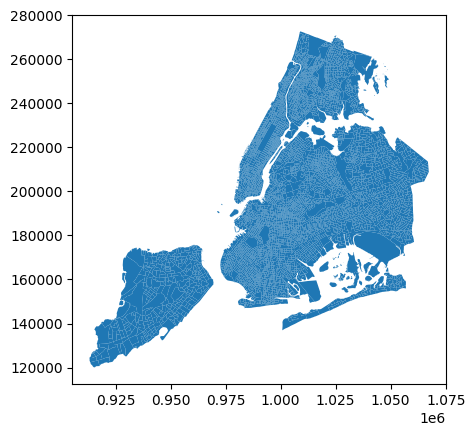

In [43]:
census_data.plot()

<Axes: >

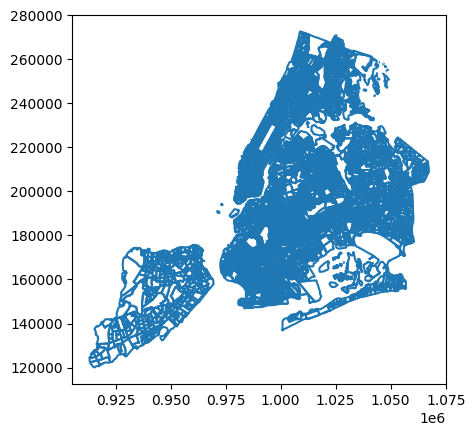

In [44]:
census_data.boundary.plot()  # plot the boundaries of the census data

<Axes: >

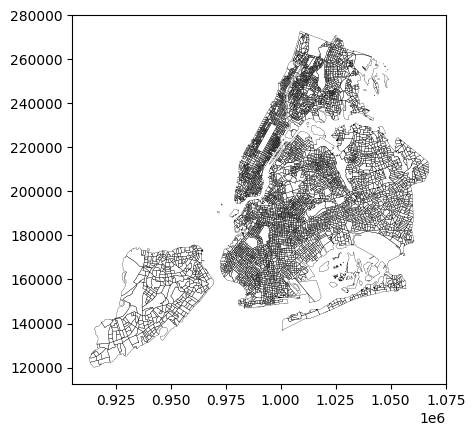

In [45]:
census_data.boundary.plot(
    linewidth=0.2, color="black"
)  # plot the boundaries of the census data

In [46]:
sheds_data = sheds_data.to_crs(
    census_data.crs
)  # convert the coordinate reference system of sheds_data to match census_data

<Axes: >

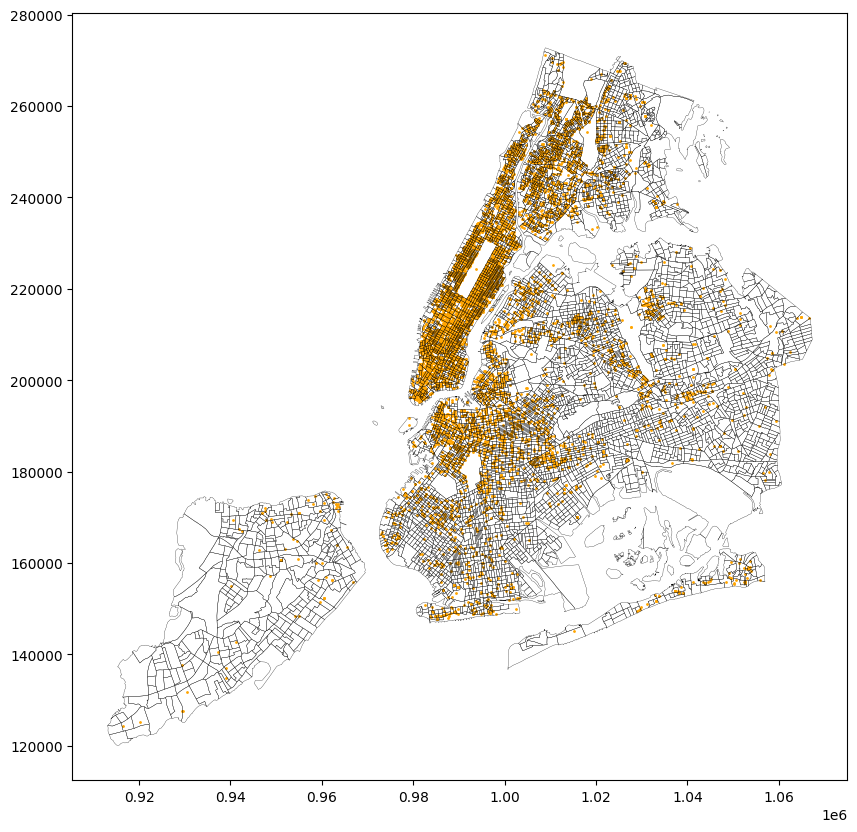

In [47]:
ax = census_data.boundary.plot(
    linewidth=0.2, color="black", figsize=(10, 10)
)  # plot the boundaries of the census data

sheds_data.plot(ax=ax, markersize=1, color="orange")